In [1]:
from dotenv import load_dotenv
import os

In [2]:
from langchain_groq import ChatGroq
groq_llm = ChatGroq(model="llama-3.1-8b-instant")

In [3]:
llm_response= groq_llm.invoke("Hello, who are you?")
llm_response.content

"I'm an artificial intelligence model known as a large language model (LLM) or a conversational AI. I'm a computer program designed to simulate human-like conversations, answer questions, and provide information on a wide range of topics.\n\nI don't have a personal identity or emotions, but I'm here to help you with any questions or topics you'd like to discuss. I can provide information, answer questions, generate text, and even create content based on your prompts.\n\nI'm constantly learning and improving my language abilities through machine learning algorithms and large datasets. However, I'm not perfect and may make mistakes or not always understand the context of a question or conversation.\n\nHow can I assist you today?"

In [4]:
from typing_extensions import TypedDict, Annotated
import operator

In [5]:
from langchain_core.messages import AnyMessage , HumanMessage, AIMessage

In [6]:
# Defining State
class GraphState(TypedDict):
    messages : Annotated[list[AnyMessage], operator.add]

In [7]:
# First Node

def llm_call(state : GraphState) -> dict:
    """Call the LLM using conversation messages and append AI Responses"""
    response = groq_llm.invoke(state["messages"])
    return {
        "messages" :[response]
        #messages" :state['messages'] + [response]
    }

In [8]:
# Second Node
def token_counter(state:GraphState)->dict:
    """Count tokens(simple word count) in the last AI Message"""
    last_msg = state['messages'][-1]
    text = last_msg.content
    token_number = len(text.split())
    Summary = f"Total token number in the generated answer (word count) is {token_number}"

    return {
       "messages" : [AIMessage(content=Summary)]
       # "messages" : state['messages']
    }

Finally, We have to Orchestrate the workflow

In [9]:
# Orchestration -> step by step executing , sequential manner
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)

# adding Nodes

builder.add_node("llm_call", llm_call)
builder.add_node("token_counter",token_counter)

In [10]:
# Add Edges
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

app=builder.compile()

visualize the Graph

In [11]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

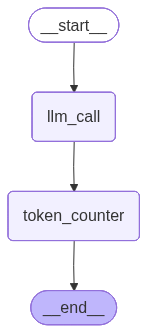

In [12]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
# Calling entire flow / Graph -> use invoke,astream

In [14]:
result = app.invoke({
    "messages" : [HumanMessage(content="Hi , This is Venkatesh,say hello in detail")]
})

In [15]:
result

{'messages': [HumanMessage(content='Hi , This is Venkatesh,say hello in detail', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello everyone, this is Venkatesh, nice to meet you all. I'm a friendly and approachable person, always eager to connect with new people and make meaningful conversations. I'm here to share my thoughts, ideas, and experiences with you all, and I hope to learn from your perspectives as well.\n\nAs we start our conversation, I'd like to tell you a bit about myself. I'm a curious and open-minded individual who's always looking for ways to grow and improve. I'm passionate about learning new things, exploring new ideas, and discovering new places.\n\nI'm a firm believer in the power of kindness, empathy, and compassion, and I strive to bring these values into my daily interactions. I'm a good listener, and I'm always willing to lend a helping hand or offer words of encouragement when needed.\n\nSo, what brings you here today? What are your intere

In [16]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Hi , This is Venkatesh,say hello in detail
AIMessage : Hello everyone, this is Venkatesh, nice to meet you all. I'm a friendly and approachable person, always eager to connect with new people and make meaningful conversations. I'm here to share my thoughts, ideas, and experiences with you all, and I hope to learn from your perspectives as well.

As we start our conversation, I'd like to tell you a bit about myself. I'm a curious and open-minded individual who's always looking for ways to grow and improve. I'm passionate about learning new things, exploring new ideas, and discovering new places.

I'm a firm believer in the power of kindness, empathy, and compassion, and I strive to bring these values into my daily interactions. I'm a good listener, and I'm always willing to lend a helping hand or offer words of encouragement when needed.

So, what brings you here today? What are your interests, hobbies, or passions? I'm all ears and excited to hear your stories and experi

In [17]:
result = app.invoke({
    "messages" : [HumanMessage(content="Good to hear you ! and Bye Now !")] 
})

In [18]:
for M in result['messages']:
    print(type(M).__name__,":", M.content)

HumanMessage : Good to hear you ! and Bye Now !
AIMessage : It was nice chatting with you, even if it was brief. If you have any questions or need assistance in the future, feel free to reach out. Have a great day and Bye for now!
AIMessage : Total token number in the generated answer (word count) is 35


In [19]:
result

{'messages': [HumanMessage(content='Good to hear you ! and Bye Now !', additional_kwargs={}, response_metadata={}),
  AIMessage(content='It was nice chatting with you, even if it was brief. If you have any questions or need assistance in the future, feel free to reach out. Have a great day and Bye for now!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 44, 'total_tokens': 85, 'completion_time': 0.088160036, 'completion_tokens_details': None, 'prompt_time': 0.006375637, 'prompt_tokens_details': None, 'queue_time': 0.083699173, 'total_time': 0.094535673}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64cd-7776-7db0-a296-a85ca8d76a6e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 41, 'total_tokens': 85}),
  AIMessage(content='Total token number 

- If you use [response], the old user message "Hello" is discarded — only the AI’s reply remains.
- If you want to keep the conversation history, you should append instead

return {
    "messages": state["messages"] + [response]
}


Tool Calling 

In [20]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [21]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [22]:
wiki_tool =WikipediaQueryRun(api_wrapper=api_wrapper)

In [23]:
wiki_tool.run({"query":"Transformers in Large language models"})

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) that provide the core capabilities of modern chatbots. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predictive power regarding synt'

In [24]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

In [25]:
tool = TavilySearchResults()
tavily_tool = tool.invoke({"query":"How is the future of LLM?"})
tavily_tool

C:\Users\Venkatesh\AppData\Local\Temp\ipykernel_14212\1476877466.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults()


[{'title': 'Future of Large Language Models - GeeksforGeeks',
  'url': 'https://www.geeksforgeeks.org/machine-learning/future-of-large-language-models/',
  'content': "## Future Prospects and Developments\n\nSeeing the demand and efficiency of LLM, the field is expected to introduce more advancements in the future. This field promises immense development shortly across domains with thorough research and experimentation. Let us explore the potential future trends in Large Language Models. [...] ## Emerging Trends in LLMs\n\nThe field of large language Models (LLMs) is evolving and consistently pushing its limitations with emerging advancements and trends. Let's look closely at the emerging trends in the LLM space. [...] In the last few years, the development of artificial intelligence has been in significant demand, with the emergence of Large Language Models (LLMs). This streamlined model entails advanced machine learning methods, has transformed natural language procedures, and is exp

In [26]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [27]:
duckduck_tool = search.invoke("what's latest news on LLM?")

Impersonate 'chrome_105' does not exist, using 'random'


In [28]:
# BingSearch , googleserpai API

In [29]:
from langchain_community.tools import YouTubeSearchTool
youtube_tool = YouTubeSearchTool()

In [30]:
youtube_tool.name

'youtube_search'

In [31]:
youtube_tool.run("LLM")

"['https://www.youtube.com/watch?v=67_aMPDk2zw&pp=ygUDTExN', 'https://www.youtube.com/watch?v=5sLYAQS9sWQ&pp=ygUDTExN']"

In [32]:
# A Simple Method , can not call run or Invoke method
def multiply(a:int , b:int)-> int:
    return a *b

multiply(10,20)

200

In [33]:
# Use @tool decorator
from langchain.tools import tool

@tool
def multiply(y:int , z:int)->any:

    """Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype"""
    
    return y*z

In [34]:
multiply.invoke({"y":50,"z":40})

2000

In [35]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Y : takes the integer input
       z : take the integer input
       return the multiplied value anytype
{'y': {'title': 'Y', 'type': 'integer'}, 'z': {'title': 'Z', 'type': 'integer'}}


In [36]:
@tool
def length_word(word:str)-> int:
    """it is a tool to count the length of the words"""
    return len(word)

In [37]:
length_word.invoke("hello large language models  and tool calling with Decorator")

60

In [38]:
length_word.args

{'word': {'title': 'Word', 'type': 'string'}}

In [39]:
import yfinance as yf

In [40]:
@tool
def get_Stock_price(ticker:str)-> str:

    """this is tool to get the stock price using yfinance"""
    try:

        stock = yf.Ticker(ticker) # ticker name of the stock

        # Get last 1 day historical data

        data = stock.history(period ="1d")

        if data.empty:
            return f"No data found for ticker {ticker} . please check the symbol"
        
        latest_close = data["Close"].iloc[-1]

        currency = stock.info.get("currency","")

        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£",
            "JPY": "¥",
            "CNY": "¥",
            "AUD": "A$",
            "CAD": "C$",
            "CHF": "CHF",
            "KRW": "₩",
            "RUB": "₽",
            "TRY": "₺",
            "BTC": "₿"
        }

        symbol =symbol_map.get(currency,"")
        currency_text = currency if currency else ""

        if symbol:
            return f"the last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}"
        else:
            return f"the last closing price of {ticker.upper()} was {latest_close:.2f}{currency_text}"


    except Exception as e:
        return f"An Error occured while fetching stock data : {str(e)}"

In [41]:
get_Stock_price.invoke("TCS.NS")

'the last closing price of TCS.NS was ₹2696.30'

In [42]:
get_Stock_price.invoke("CTS")

'the last closing price of CTS was $57.46'

In [43]:
get_Stock_price.invoke("AAPL")

'the last closing price of AAPL was $255.78'

In [44]:
get_Stock_price.invoke("TSLA")

'the last closing price of TSLA was $417.44'

In [45]:
get_Stock_price.invoke("HDFC")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HDFC"}}}
$HDFC: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


'No data found for ticker HDFC . please check the symbol'

How LLM's will decide which tool needs to be call

In [46]:
# Define List of all tools - in List
tools =[get_Stock_price,multiply,length_word,wiki_tool]

In [47]:
# bind with the LLM
llm_with_tools = groq_llm.bind_tools(tools)

In [48]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [49]:
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '42km2mzzd', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_Stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 507, 'total_tokens': 526, 'completion_time': 0.0431746, 'completion_tokens_details': None, 'prompt_time': 0.042409452, 'prompt_tokens_details': None, 'queue_time': 0.059165578, 'total_time': 0.085584052}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64ce-15c0-70a1-ad8d-ec45ec15292c-0', tool_calls=[{'name': 'get_Stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': '42km2mzzd', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 507, 'output_tokens': 19, 'total_tokens': 526})

In [50]:
result.tool_calls

[{'name': 'get_Stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': '42km2mzzd',
  'type': 'tool_call'}]

In [51]:
result.content

''

In [52]:
word_length_tool= llm_with_tools.invoke("How many words in the sentence, 'Hello world , this is a test sentence' ")
word_length_tool

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8qjh9ncrh', 'function': {'arguments': '{"word":"Hello world , this is a test sentence"}', 'name': 'length_word'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 514, 'total_tokens': 535, 'completion_time': 0.026990085, 'completion_tokens_details': None, 'prompt_time': 0.032794779, 'prompt_tokens_details': None, 'queue_time': 0.05397739, 'total_time': 0.059784864}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_ff2b098aaf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64ce-1768-7b33-b232-69090a1b3e23-0', tool_calls=[{'name': 'length_word', 'args': {'word': 'Hello world , this is a test sentence'}, 'id': '8qjh9ncrh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 514, 'output_tokens': 21, 'total_tokens': 535})

In [53]:
word_length_tool.tool_calls

[{'name': 'length_word',
  'args': {'word': 'Hello world , this is a test sentence'},
  'id': '8qjh9ncrh',
  'type': 'tool_call'}]

In [54]:
multiply_tool= llm_with_tools.invoke("what is the multiplication of 2 and 3?")
multiply_tool

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'kvp804asr', 'function': {'arguments': '{"y":2,"z":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 507, 'total_tokens': 526, 'completion_time': 0.03790299, 'completion_tokens_details': None, 'prompt_time': 0.040488286, 'prompt_tokens_details': None, 'queue_time': 0.044887033, 'total_time': 0.078391276}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64ce-1859-7121-9edf-00896e5e68fc-0', tool_calls=[{'name': 'multiply', 'args': {'y': 2, 'z': 3}, 'id': 'kvp804asr', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 507, 'output_tokens': 19, 'total_tokens': 526})

In [55]:
multiply_tool.tool_calls

[{'name': 'multiply',
  'args': {'y': 2, 'z': 3},
  'id': 'kvp804asr',
  'type': 'tool_call'}]

In [56]:
# Normal scenario, with out tool, LLM giving answer
normal_question= llm_with_tools.invoke("Hi , How are you?")

In [57]:
normal_question

AIMessage(content="I'm functioning properly, thank you for asking. What do you need help with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 502, 'total_tokens': 521, 'completion_time': 0.02727453, 'completion_tokens_details': None, 'prompt_time': 0.037300773, 'prompt_tokens_details': None, 'queue_time': 0.046254627, 'total_time': 0.064575303}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c64ce-194e-7fa0-8b86-b82b03e05ebd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 502, 'output_tokens': 19, 'total_tokens': 521})

In [58]:
normal_question.tool_calls

[]

In [59]:
tool_calling_question= llm_with_tools.invoke("what was the latest india union budget of India 2026? ")

In [60]:
tool_calling_question.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'India Union Budget 2026'},
  'id': 'atqm76j4x',
  'type': 'tool_call'},
 {'name': 'wikipedia',
  'args': {'query': 'India Union Budget 2026 latest'},
  'id': 'afgmg3a2r',
  'type': 'tool_call'}]

In [61]:
tool_calling_question.content

''